# Improving Multi-class Text Classification Accuracy Using Fuzzy Logic and NLP Techniques

## 1. Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt

import contractions
import spacy
from symspellpy import SymSpell, Verbosity
import pkg_resources

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

nlp = spacy.load("en_core_web_sm")

In [4]:

def load_dataset(path="C:/Users/Kaushal/Downloads/archive (3)/News_Category_Dataset_v3.json"):
    df = pd.read_json(path, lines=True)
    return df

# Create the DataFrame
df = load_dataset()

print(df.head())
df.head()

                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


## 2. Data Exploration

In [5]:
print(f"Total records     : {len(df):,}")
print(f"Number of classes : {df['category'].nunique()}")
print(df.isna().sum())

Total records     : 209,527
Number of classes : 42
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64


In [6]:
counts = df["category"].value_counts()
ratio = counts.max() / counts.min()
print(f"Largest class:  {counts.idxmax()} ({counts.max()} articles)")
print(f"Smallest class: {counts.idxmin()} ({counts.min()} articles)")
print(f"Imbalance ratio: {ratio:.1f}")
print(counts.head(15))

Largest class:  POLITICS (35602 articles)
Smallest class: EDUCATION (1014 articles)
Imbalance ratio: 35.1
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
Name: count, dtype: int64


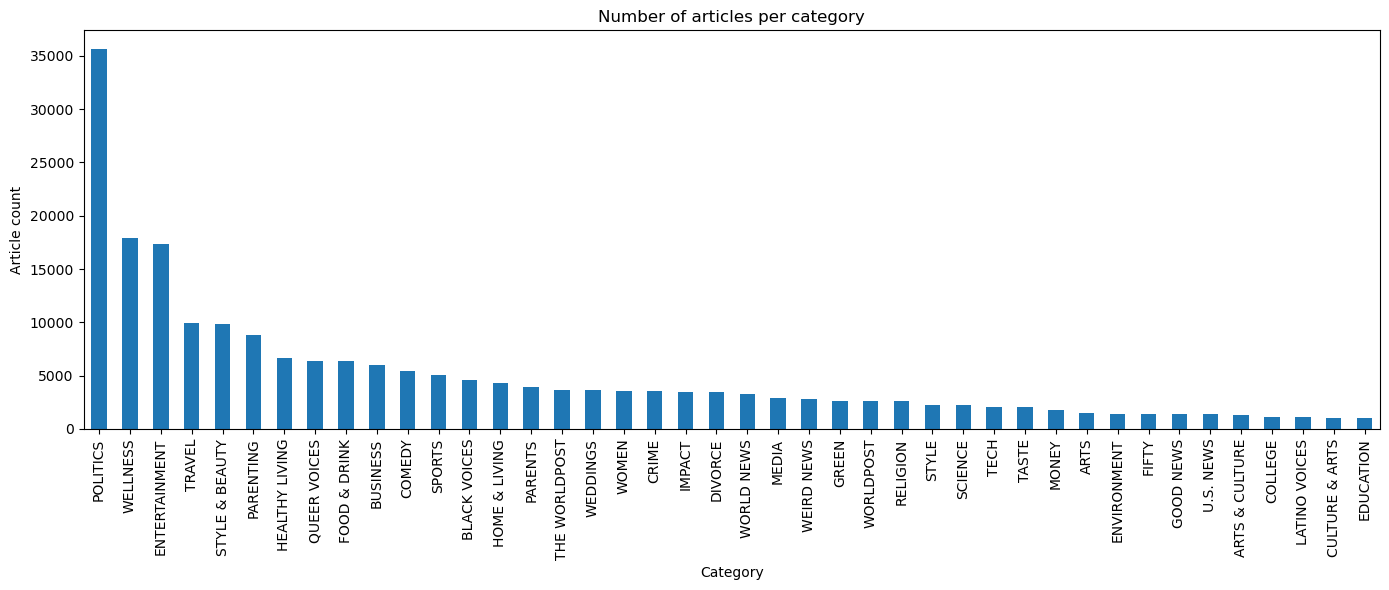

In [7]:
plt.figure(figsize=(14, 6))
counts.plot(kind="bar")
plt.title("Number of articles per category")
plt.xlabel("Category")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()

## 3. Text Preprocessing

### 3.1 Lowercasing

In [8]:
for col in ["category", "headline", "short_description", "authors"]:
    df[col] = df[col].str.lower()
df.head(3)

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,over 4 million americans roll up sleeves for o...,u.s. news,health experts said it is too early to predict...,"carla k. johnson, ap",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"american airlines flyer charged, banned for li...",u.s. news,he was subdued by passengers and crew when he ...,mary papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 of the funniest tweets about cats and dogs ...,comedy,"""until you have a dog you don't understand wha...",elyse wanshel,2022-09-23


### 3.2 Contraction Expansion

In [9]:
cols = ["headline", "short_description"]
df[cols] = df[cols].apply(
    lambda col: col.apply(lambda x: contractions.fix(str(x)) if pd.notna(x) else x)
)
df.head(3)

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,over 4 million americans roll up sleeves for o...,u.s. news,health experts said it is too early to predict...,"carla k. johnson, ap",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"american airlines flyer charged, banned for li...",u.s. news,he was subdued by passengers and crew when he ...,mary papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 of the funniest tweets about cats and dogs ...,comedy,"""until you have a dog you do not understand wh...",elyse wanshel,2022-09-23


### 3.3 Punctuation Removal

In [10]:
exclude = string.punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', exclude))

df[["headline", "short_description"]] = df[["headline", "short_description"]].applymap(remove_punctuation)
df.head(3)

C:\Users\Kaushal\AppData\Local\Temp\ipykernel_23952\1486137968.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[["headline", "short_description"]] = df[["headline", "short_description"]].applymap(remove_punctuation)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,over 4 million americans roll up sleeves for o...,u.s. news,health experts said it is too early to predict...,"carla k. johnson, ap",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,american airlines flyer charged banned for lif...,u.s. news,he was subdued by passengers and crew when he ...,mary papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 of the funniest tweets about cats and dogs ...,comedy,until you have a dog you do not understand wha...,elyse wanshel,2022-09-23


### 3.4 Spelling Correction

In [11]:
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
dictionary_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

df[["headline", "short_description"]] = df[["headline", "short_description"]].applymap(correct_spelling)
df.head(3)

C:\Users\Kaushal\AppData\Local\Temp\ipykernel_23952\4100848076.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[["headline", "short_description"]] = df[["headline", "short_description"]].applymap(correct_spelling)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,over a million americans roll up sleeves for o...,u.s. news,health experts said it is too early to predict...,"carla k. johnson, ap",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,american airlines flyer charged banned for lif...,u.s. news,he was subdued by passengers and crew when he ...,mary papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,of of the funniest sweets about cats and dogs ...,comedy,until you have a dog you do not understand wha...,elyse wanshel,2022-09-23


### 3.5 Stopword Removal and Lemmatization

In [12]:
def preprocess_batch(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=500, disable=["parser", "ner"]):
        tokens = [token.lemma_ for token in doc if not token.is_stop]
        results.append(" ".join(tokens))
    return results

df["headline"] = preprocess_batch(df["headline"].astype(str))
df["short_description"] = preprocess_batch(df["short_description"].astype(str))
df.head(3)

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,million americans roll sleeve omicron target c...,u.s. news,health expert say early predict demand match m...,"carla k. johnson, ap",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,american airlines flyer charge ban life punch ...,u.s. news,subdue passenger crew flee aircraft confrontat...,mary papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,funniest sweet cat dog week sept,comedy,dog understand eat,elyse wanshel,2022-09-23


### 3.6 Combine Fields and Save

In [13]:
df["text"] = df["headline"] + " " + df["short_description"]
df.to_csv("cleaned_news.csv", index=False)
print("Saved. Shape:", df.shape)
df[["category", "text"]].head()

Saved. Shape: (209527, 7)


,category,text
0,u.s. news,million americans roll sleeve omicron target c...
1,u.s. news,american airlines flyer charge ban life punch ...
2,comedy,funniest sweet cat dog week sept dog understan...
3,parenting,funniest sweet parent week sept accidentally g...
4,u.s. news,woman call cop black birdwatcher lose lawsuit ...


## 4. Feature Engineering

### 4.1 Label Encoding and Train/Test Split

In [14]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["category"])
print("Number of classes:", len(encoder.classes_))

X_text = df["text"].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", len(X_train), "| Test:", len(X_test))

Number of classes: 42
Train: 167621 | Test: 41906


### 4.2 TF-IDF Vectorisation

In [15]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Feature matrix shape:", X_train_tfidf.shape)

Feature matrix shape: (167621, 20000)


### 4.3 Dimensionality Reduction (SVD)

In [16]:
svd = TruncatedSVD(n_components=1000, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_svd)
X_test_scaled = scaler.transform(X_test_svd)

print("Before SVD:", X_train_tfidf.shape[1], "features")
print("After SVD :", X_train_scaled.shape[1], "features")
print("Variance kept:", round(svd.explained_variance_ratio_.sum(), 3))

Before SVD: 20000 features
After SVD : 1000 features
Variance kept: 0.384


## 5. Baseline Models

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print("Naive Bayes Accuracy        :", accuracy_score(y_test, nb_model.predict(X_test_tfidf)))

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
print("Linear SVM Accuracy         :", accuracy_score(y_test, svm_model.predict(X_test_tfidf)))

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf, y_train)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_model.predict(X_test_tfidf)))

Naive Bayes Accuracy        : 0.5114542070347922
Linear SVM Accuracy         : 0.5974800744523457
Logistic Regression Accuracy: 0.6012026917386531


## 6. Type-1 Fuzzy Classifier

In [18]:
def fit_fuzzy(X, y):
    classes = np.unique(y)
    means, sigmas = {}, {}
    for k in classes:
        X_k = X[y == k]
        means[k] = np.mean(X_k, axis=0)
        sigmas[k] = np.std(X_k, axis=0) + 1e-6
    return classes, means, sigmas

def predict_fuzzy(X, classes, means, sigmas):
    scores = np.zeros((X.shape[0], len(classes)))
    for i, k in enumerate(classes):
        membership = np.exp(-((X - means[k])**2) / (2 * sigmas[k]**2))
        scores[:, i] = np.log(membership + 1e-12).sum(axis=1)
    return classes[np.argmax(scores, axis=1)]

In [19]:
n = 20000
Xtr_sub = X_train_scaled[:n]
ytr_sub = y_train[:n]

classes, means, sigmas = fit_fuzzy(Xtr_sub, ytr_sub)
fuzzy_pred = predict_fuzzy(X_test_scaled, classes, means, sigmas)
print("Type-1 Fuzzy accuracy:", accuracy_score(y_test, fuzzy_pred))

Type-1 Fuzzy accuracy: 0.24488140123132726


## 7. Interval Type-2 Fuzzy Classifier

In [20]:
def it2_fit(X, y, uncertainty=0.3):
    classes = np.unique(y)
    means, sigmas = {}, {}
    for k in classes:
        X_k = X[y == k]
        means[k] = np.mean(X_k, axis=0)
        sigmas[k] = np.std(X_k, axis=0) + 1e-6
    return classes, means, sigmas

def it2_predict(X, classes, means, sigmas, uncertainty=0.3):
    scores = np.zeros((X.shape[0], len(classes)))
    for i, k in enumerate(classes):
        sigma_upper = sigmas[k] * (1 + uncertainty)
        sigma_lower = sigmas[k] * (1 - uncertainty)
        upper_membership = np.exp(-((X - means[k])**2) / (2 * sigma_upper**2))
        lower_membership = np.exp(-((X - means[k])**2) / (2 * sigma_lower**2))
        upper_firing = np.log(upper_membership + 1e-12).sum(axis=1)
        lower_firing = np.log(lower_membership + 1e-12).sum(axis=1)
        scores[:, i] = (upper_firing + lower_firing) / 2.0
    return classes[np.argmax(scores, axis=1)]

In [21]:
classes, means, sigmas = it2_fit(X_train_scaled, y_train, uncertainty=0.3)
it2_pred = it2_predict(X_test_scaled, classes, means, sigmas, uncertainty=0.3)
print("Interval Type-2 Fuzzy accuracy:", accuracy_score(y_test, it2_pred))

Interval Type-2 Fuzzy accuracy: 0.22182980957380805


### 7.1 Uncertainty Factor Tuning

In [22]:
for u in [0.1, 0.2, 0.3, 0.5, 0.7]:
    classes, means, sigmas = it2_fit(Xtr_sub, ytr_sub, uncertainty=u)
    pred = it2_predict(X_test_scaled, classes, means, sigmas, uncertainty=u)
    print(f"uncertainty={u}: accuracy={accuracy_score(y_test, pred):.4f}")

uncertainty=0.1: accuracy=0.2444
uncertainty=0.2: accuracy=0.2433
uncertainty=0.3: accuracy=0.2407
uncertainty=0.5: accuracy=0.2318
uncertainty=0.7: accuracy=0.2081


## 8. Model Evaluation and Comparison

In [23]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

results = []
results.append(evaluate_model("Naive Bayes", y_test, nb_model.predict(X_test_tfidf)))
results.append(evaluate_model("Linear SVM", y_test, svm_model.predict(X_test_tfidf)))
results.append(evaluate_model("Logistic Regression", y_test, log_model.predict(X_test_tfidf)))

t1_c, t1_m, t1_s = fit_fuzzy(Xtr_sub, ytr_sub)
results.append(evaluate_model("Type-1 Fuzzy", y_test, predict_fuzzy(X_test_scaled, t1_c, t1_m, t1_s)))

it2_c, it2_m, it2_s = it2_fit(Xtr_sub, ytr_sub, uncertainty=0.3)
results.append(evaluate_model("Interval Type-2 Fuzzy", y_test,
                              it2_predict(X_test_scaled, it2_c, it2_m, it2_s, uncertainty=0.3)))

comparison = pd.DataFrame(results).set_index("Model").round(4)
comparison.to_csv("model_comparison.csv")
print(comparison.to_string())

                       Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)
Model                                                                                        
Naive Bayes              0.5115             0.5869          0.2381      0.2574         0.4343
Linear SVM               0.5975             0.4994          0.4427      0.4622         0.5818
Logistic Regression      0.6012             0.5590          0.4158      0.4523         0.5746
Type-1 Fuzzy             0.2449             0.4299          0.1547      0.1574         0.2037
Interval Type-2 Fuzzy    0.2407             0.4355          0.1515      0.1538         0.1960


## 9. Word2Vec Feature Representation

### 9.1 Train Word2Vec and Build Document Vectors

In [24]:
from gensim.models import Word2Vec

sentences = [text.split() for text in df["text"].astype(str)]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)
print("Vocabulary size:", len(w2v_model.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulary size: 32871


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [25]:
def document_vector(doc, model, size=100):
    words = doc.split()
    word_vectors = [model.wv[w] for w in words if w in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(size)
    return np.mean(word_vectors, axis=0)

X_w2v = np.array([document_vector(text, w2v_model) for text in df["text"].astype(str)])
print("Document vectors shape:", X_w2v.shape)

Document vectors shape: (209527, 100)


### 9.2 Scale, Split and Evaluate

In [26]:
scaler_w2v = MinMaxScaler()
X_w2v_scaled = scaler_w2v.fit_transform(X_w2v)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_w2v_scaled, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", Xw_train.shape, "Test:", Xw_test.shape)

Train: (167621, 100) Test: (41906, 100)


In [27]:
it2_c, it2_m, it2_s = it2_fit(Xw_train, yw_train, uncertainty=0.3)
it2_pred = it2_predict(Xw_test, it2_c, it2_m, it2_s, uncertainty=0.3)
print("IT2 Fuzzy (Word2Vec)    - Acc:", round(accuracy_score(yw_test, it2_pred), 4),
      "| Macro F1:", round(f1_score(yw_test, it2_pred, average='macro', zero_division=0), 4))

t1_c, t1_m, t1_s = fit_fuzzy(Xw_train, yw_train)
t1_pred = predict_fuzzy(Xw_test, t1_c, t1_m, t1_s)
print("Type-1 Fuzzy (Word2Vec) - Acc:", round(accuracy_score(yw_test, t1_pred), 4),
      "| Macro F1:", round(f1_score(yw_test, t1_pred, average='macro', zero_division=0), 4))

IT2 Fuzzy (Word2Vec)    - Acc: 0.2877 | Macro F1: 0.2251
Type-1 Fuzzy (Word2Vec) - Acc: 0.2877 | Macro F1: 0.2251


In [28]:
svm_w2v = LinearSVC()
svm_w2v.fit(Xw_train, yw_train)
svm_pred = svm_w2v.predict(Xw_test)
print("SVM (Word2Vec)    - Acc:", round(accuracy_score(yw_test, svm_pred), 4),
      "| Macro F1:", round(f1_score(yw_test, svm_pred, average='macro', zero_division=0), 4))

logreg_w2v = LogisticRegression(max_iter=1000)
logreg_w2v.fit(Xw_train, yw_train)
lr_pred = logreg_w2v.predict(Xw_test)
print("LogReg (Word2Vec) - Acc:", round(accuracy_score(yw_test, lr_pred), 4),
      "| Macro F1:", round(f1_score(yw_test, lr_pred, average='macro', zero_division=0), 4))

SVM (Word2Vec)    - Acc: 0.5344 | Macro F1: 0.313
LogReg (Word2Vec) - Acc: 0.5519 | Macro F1: 0.3852


## 10. Ontological Structuring with WordNet

### 10.1 Setup

In [29]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

synsets = wn.synsets("health")
print("Synsets for 'health':", synsets)
print("Definition:", synsets[0].definition())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kaushal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Kaushal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Synsets for 'health': [Synset('health.n.01'), Synset('health.n.02')]
Definition: a healthy state of wellbeing free from disease


### 10.2 Word Similarity

In [30]:
def word_similarity(word1, word2):
    s1, s2 = wn.synsets(word1), wn.synsets(word2)
    if not s1 or not s2:
        return 0.0
    return s1[0].wup_similarity(s2[0]) or 0.0

print("health vs wellness    :", word_similarity("health", "wellness"))
print("health vs sports      :", word_similarity("health", "sports"))
print("politics vs government:", word_similarity("politics", "government"))
print("food vs politics      :", word_similarity("food", "politics"))

health vs wellness    : 1.0
health vs sports      : 0.2222222222222222
politics vs government: 0.3333333333333333
food vs politics      : 0.2


### 10.3 Map Categories to Keywords

In [31]:
categories = df["category"].unique()

def get_keyword(category):
    words = category.replace("&", " ").replace(".", " ").split()
    for word in words:
        word = word.strip().lower()
        if wn.synsets(word):
            return word
    return None

category_keywords = {cat: get_keyword(cat) for cat in categories}

manual_fixes = {
    "u.s. news": "news", "worldpost": "world", "the worldpost": "world",
    "world news": "news", "fifty": "age", "good news": "news",
    "weird news": "news", "impact": "influence", "queer voices": "gay",
    "black voices": "race", "latino voices": "race", "green": "environment",
    "taste": "food", "healthy living": "health", "wellness": "health",
}
category_keywords.update({c: k for c, k in manual_fixes.items() if c in category_keywords})

for cat, kw in category_keywords.items():
    print(f"{cat:20} -> {kw}")

u.s. news            -> news
comedy               -> comedy
parenting            -> parenting
world news           -> news
culture & arts       -> culture
tech                 -> tech
sports               -> sports
entertainment        -> entertainment
politics             -> politics
weird news           -> news
environment          -> environment
education            -> education
crime                -> crime
science              -> science
wellness             -> health
business             -> business
style & beauty       -> style
food & drink         -> food
media                -> media
queer voices         -> gay
home & living        -> home
women                -> women
black voices         -> race
travel               -> travel
money                -> money
religion             -> religion
latino voices        -> race
impact               -> influence
weddings             -> weddings
college              -> college
parents              -> parents
arts & culture       -> arts
s

### 10.4 Similarity Matrix

In [32]:
def keyword_similarity(kw1, kw2):
    s1, s2 = wn.synsets(kw1), wn.synsets(kw2)
    if not s1 or not s2:
        return 0.0
    return s1[0].wup_similarity(s2[0]) or 0.0

cats = list(category_keywords.keys())
n = len(cats)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        kw_i, kw_j = category_keywords[cats[i]], category_keywords[cats[j]]
        if kw_i and kw_j:
            sim_matrix[i, j] = keyword_similarity(kw_i, kw_j)

print("Similarity matrix shape:", sim_matrix.shape)

Similarity matrix shape: (42, 42)


### 10.5 Cluster into Ontological Groups

In [33]:
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict

distance_matrix = 1 - sim_matrix
n_clusters = 10
clustering = AgglomerativeClustering(
    n_clusters=n_clusters, metric="precomputed", linkage="average")
cluster_labels = clustering.fit_predict(distance_matrix)

groups = defaultdict(list)
for cat, label in zip(cats, cluster_labels):
    groups[label].append(cat)

for label, members in sorted(groups.items()):
    print(f"Group {label}: {members}\n")

Group 0: ['sports', 'entertainment', 'education', 'crime', 'science', 'black voices', 'travel', 'religion', 'latino voices', 'weddings', 'arts & culture', 'arts', 'divorce']

Group 1: ['u.s. news', 'comedy', 'world news', 'weird news', 'good news']

Group 2: ['environment', 'wellness', 'style & beauty', 'impact', 'style', 'green', 'healthy living', 'fifty']

Group 3: ['media', 'queer voices', 'women', 'parents', 'the worldpost', 'worldpost']

Group 4: ['money']

Group 5: ['parenting']

Group 6: ['culture & arts', 'tech', 'business', 'college']

Group 7: ['food & drink', 'taste']

Group 8: ['politics']

Group 9: ['home & living']



### 10.6 Classify at Group Level

In [34]:
cat_to_group = {cat: label for cat, label in zip(cats, cluster_labels)}
df["group"] = df["category"].map(cat_to_group)

group_encoder = LabelEncoder()
y_group = group_encoder.fit_transform(df["group"])

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_w2v_scaled, y_group, test_size=0.2, stratify=y_group, random_state=42)

g_c, g_m, g_s = it2_fit(Xg_train, yg_train, uncertainty=0.3)
group_pred = it2_predict(Xg_test, g_c, g_m, g_s, uncertainty=0.3)

print("Fuzzy accuracy at GROUP level (10 groups):", round(accuracy_score(yg_test, group_pred), 4))
print("Fuzzy accuracy at FLAT level (42 classes):", 0.2884)

Fuzzy accuracy at GROUP level (10 groups): 0.4966
Fuzzy accuracy at FLAT level (42 classes): 0.2884
